In [4]:
import pandas as pd
import seaborn as sns
from sklearn.model_selection import train_test_split,GridSearchCV
from sklearn.svm import SVC
from sklearn.metrics import classification_report
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import OneHotEncoder, RobustScaler
from sklearn.compose import ColumnTransformer

In [5]:
df = pd.read_csv("datasets/titanic.csv")

In [6]:
df.head()

,pclass,name,sex,age,sibsp,parch,ticket,fare,cabin,embarked,survived
0,1,"Allen, Miss. Elisabeth Walton",female,29.0000,0,0,24160,211.3375,B5,S,1
1,1,"Allison, Master. Hudson Trevor",male,0.9167,1,2,113781,151.5500,C22 C26,S,1
2,1,"Allison, Miss. Helen Loraine",female,2.0000,1,2,113781,151.5500,C22 C26,S,0
3,1,"Allison, Mr. Hudson Joshua Creighton",male,30.0000,1,2,113781,151.5500,C22 C26,S,0
4,1,"Allison, Mrs. Hudson J C (Bessie Waldo Daniels)",female,25.0000,1,2,113781,151.5500,C22 C26,S,0


In [ ]:
df.drop(columns = ['PassengerId','Name','Ticket','Cabin'], inplace = True)

In [8]:
df.isna().sum()

Survived      0
Pclass        0
Sex           0
Age         177
SibSp         0
Parch         0
Fare          0
Embarked      2
dtype: int64

In [9]:
df['Age'] = df['Age'].fillna(df['Age'].median())

In [10]:
df['Embarked'] = df['Embarked'].fillna(df['Embarked'].mode()[0])

In [11]:
df.isna().sum()

Survived    0
Pclass      0
Sex         0
Age         0
SibSp       0
Parch       0
Fare        0
Embarked    0
dtype: int64

In [12]:
x=df.drop(columns='Survived')
y=df.Survived

In [13]:
xtrain,xtest,ytrain,ytest = train_test_split(x,y,random_state=42,train_size=0.2)

In [14]:
num_cols = x.select_dtypes(include='number').columns
obj_cols=x.select_dtypes(include='object').columns

In [15]:
obj_cols

Index(['Sex', 'Embarked'], dtype='object')

<Axes: >

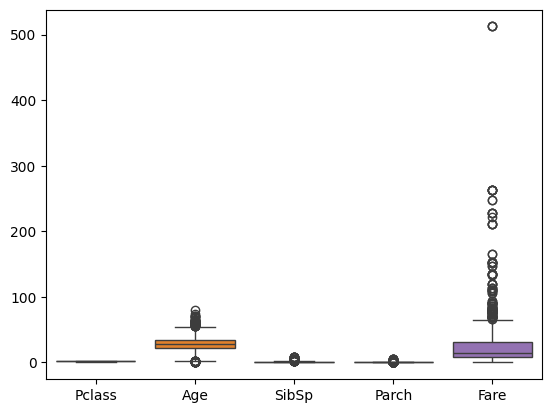

In [16]:
sns.boxplot(x[num_cols])

In [17]:
x[obj_cols].nunique()

Sex         2
Embarked    3
dtype: int64

In [18]:
preprocessing=ColumnTransformer(
    transformers=[
        ('scaling',RobustScaler(),num_cols),
        ('onehotencoder',OneHotEncoder(sparse_output=False,handle_unknown='ignore'),
                obj_cols)
    ],remainder="passthrough"
)

In [19]:
pipeline = Pipeline(
    steps=[("preprocessing",preprocessing),
          ('model',SVC(random_state=42))
          ]
        )

In [20]:
grid_search_cv=GridSearchCV(
    estimator=pipeline,
    param_grid={
        'model__C':[0.01,0.1,1.0,10,100],
        'model__kernel':['linear','rbf','poly','sigmoid']
    },
    verbose=10,
    n_jobs=-1 
)

In [21]:
grid_search_cv.fit(xtrain,ytrain)

Fitting 5 folds for each of 20 candidates, totalling 100 fits


,"estimator estimator: estimator objectThis is assumed to implement the scikit-learn estimator interface.Either estimator needs to provide a ``score`` function,or ``scoring`` must be passed.",Pipeline(step...m_state=42))])
,"param_grid param_grid: dict or list of dictionariesDictionary with parameters names (`str`) as keys and lists ofparameter settings to try as values, or a list of suchdictionaries, in which case the grids spanned by each dictionaryin the list are explored. This enables searching over any sequenceof parameter settings.","{'model__C': [0.01, 0.1, ...], 'model__kernel': ['linear', 'rbf', ...]}"
,"scoring scoring: str, callable, list, tuple or dict, default=NoneStrategy to evaluate the performance of the cross-validated model onthe test set.If `scoring` represents a single score, one can use:- a single string (see :ref:`scoring_string_names`);- a callable (see :ref:`scoring_callable`) that returns a single value;- `None`, the `estimator`'s :ref:`default evaluation criterion ` is used.If `scoring` represents multiple scores, one can use:- a list or tuple of unique strings;- a callable returning a dictionary where the keys are the metric names and the values are the metric scores;- a dictionary with metric names as keys and callables as values.See :ref:`multimetric_grid_search` for an example.",None
,"n_jobs n_jobs: int, default=NoneNumber of jobs to run in parallel.``None`` means 1 unless in a :obj:`joblib.parallel_backend` context.``-1`` means using all processors. See :term:`Glossary `for more details... versionchanged:: v0.20 `n_jobs` default changed from 1 to None",-1
,"refit refit: bool, str, or callable, default=TrueRefit an estimator using the best found parameters on the wholedataset.For multiple metric evaluation, this needs to be a `str` denoting thescorer that would be used to find the best parameters for refittingthe estimator at the end.Where there are considerations other than maximum score inchoosing a best estimator, ``refit`` can be set to a function whichreturns the selected ``best_index_`` given ``cv_results_``. In thatcase, the ``best_estimator_`` and ``best_params_`` will be setaccording to the returned ``best_index_`` while the ``best_score_``attribute will not be available.The refitted estimator is made available at the ``best_estimator_``attribute and permits using ``predict`` directly on this``GridSearchCV`` instance.Also for multiple metric evaluation, the attributes ``best_index_``,``best_score_`` and ``best_params_`` will only be available if``refit`` is set and all of them will be determined w.r.t this specificscorer.See ``scoring`` parameter to know more about multiple metricevaluation.See :ref:`sphx_glr_auto_examples_model_selection_plot_grid_search_digits.py`to see how to design a custom selection strategy using a callablevia `refit`.See :ref:`this example`for an example of how to use ``refit=callable`` to balance modelcomplexity and cross-validated score... versionchanged:: 0.20 Support for callable added.",True
,"cv cv: int, cross-validation generator or an iterable, default=NoneDetermines the cross-validation splitting strategy.Possible inputs for cv are:- None, to use the default 5-fold cross validation,- integer, to specify the number of folds in a `(Stratified)KFold`,- :term:`CV splitter`,- An iterable yielding (train, test) splits as arrays of indices.For integer/None inputs, if the estimator is a classifier and ``y`` iseither binary or multiclass, :class:`StratifiedKFold` is used. In allother cases, :class:`KFold` is used. These splitters are instantiatedwith `shuffle=False` so the splits will be the same across calls.Refer :ref:`User Guide ` for the variouscross-validation strategies that can be used here... versionchanged:: 0.22 ``cv`` default value if None changed from 3-fold to 5-fold.",None
,"verbose verbose: intControls the verbosity: the higher, the more messages.- >1 : the computation time for each fold and parameter candidate is displayed;- >2 : the score is also 

In [22]:
grid_search_cv.best_estimator_ # It will return the best model/estimator

,"steps steps: list of tuplesList of (name of step, estimator) tuples that are to be chained insequential order. To be compatible with the scikit-learn API, all stepsmust define `fit`. All non-last steps must also define `transform`. See:ref:`Combining Estimators ` for more details.","[('preprocessing', ...), ('model', ...)]"
,"transform_input transform_input: list of str, default=NoneThe names of the :term:`metadata` parameters that should be transformed by thepipeline before passing it to the step consuming it.This enables transforming some input arguments to ``fit`` (other than ``X``)to be transformed by the steps of the pipeline up to the step which requiresthem. Requirement is defined via :ref:`metadata routing `.For instance, this can be used to pass a validation set through the pipeline.You can only set this if metadata routing is enabled, which youcan enable using ``sklearn.set_config(enable_metadata_routing=True)``... versionadded:: 1.6",None
,"memory memory: str or object with the joblib.Memory interface, default=NoneUsed to cache the fitted transformers of the pipeline. The last stepwill never be cached, even if it is a transformer. By default, nocaching is performed. If a string is given, it is the path to thecaching directory. Enabling caching triggers a clone of the transformersbefore fitting. Therefore, the transformer instance given to thepipeline cannot be inspected directly. Use the attribute ``named_steps``or ``steps`` to inspect estimators within the pipeline. Caching thetransformers is advantageous when fitting is time consuming. See:ref:`sphx_glr_auto_examples_neighbors_plot_caching_nearest_neighbors.py`for an example on how to enable caching.",None
,"verbose verbose: bool, default=FalseIf True, the time elapsed while fitting each step will be printed as itis completed.",False
,"transformers transformers: list of tuplesList of (name, transformer, columns) tuples specifying thetransformer objects to be applied to subsets of the data.name : str Like in Pipeline and FeatureUnion, this allows the transformer and its parameters to be set using ``set_params`` and searched in grid search.transformer : {'drop', 'passthrough'} or estimator Estimator must support :term:`fit` and :term:`transform`. Special-cased strings 'drop' and 'passthrough' are accepted as well, to indicate to drop the columns or to pass them through untransformed, respectively.columns : str, array-like of str, int, array-like of int, array-like of bool, slice or callable Indexes the data on its second axis. Integers are interpreted as positional columns, while strings can reference DataFrame columns by name. A scalar string or int should be used where ``transformer`` expects X to be a 1d array-like (vector), otherwise a 2d array will be passed to the transformer. A callable is passed the input data `X` and can return any of the above. To select multiple columns by name or dtype, you can use :obj:`make_column_selector`.","[('scaling', ...), ('onehotencoder', ...)]"
,"remainder remainder: {'drop', 'passthrough'} or estimator, default='drop'By default, only the specified columns in `transformers` aretransformed and combined in the output, and the non-specifiedcolumns are dropped. (default of ``'drop'``).By specifying ``remainder='passthrough'``, all remaining columns thatwere not specified in `transformers`, but present in the data passedto `fit` will be automatically passed through. This subset of columnsis concatenated with the output of the transformers. For dataframes,extra columns not seen during `fit` will be excluded from the outputof `transform`.By setting ``remainder`` to be an estimator, the remainingnon-specified columns will use the ``remainder`` estimator. Theestimator must support :term:`fit` and :term:`transform`.Note that using this feature requires that the DataFrame columnsinput at :term:`fit` and :term:`transform` have identical order.",'passthrough'
,"sparse_threshold sparse_threshold: float, default=0.3If the output of the dif

In [23]:
grid_search_cv.best_params_ # it will return the best parameter values

{'model__C': 0.1, 'model__kernel': 'linear'}

In [24]:
grid_search_cv.cv_results_

{'mean_fit_time': array([0.02513289, 0.02435226, 0.0167274 , 0.01913004, 0.01733494,
        0.01649709, 0.01595397, 0.01772666, 0.01624069, 0.01735086,
        0.01737309, 0.0163846 , 0.01528997, 0.01710954, 0.02239885,
        0.01651092, 0.02357373, 0.0209146 , 0.0198926 , 0.01628323]),
 'std_fit_time': array([0.00414326, 0.00720371, 0.003077  , 0.00458089, 0.00260174,
        0.00195517, 0.00070821, 0.00119801, 0.00234568, 0.00199239,
        0.00205064, 0.00100835, 0.00092826, 0.00198445, 0.00558645,
        0.00202024, 0.00163992, 0.00303734, 0.00234672, 0.00286342]),
 'mean_score_time': array([0.01021595, 0.00862036, 0.00869274, 0.00881281, 0.00767674,
        0.00916619, 0.00859323, 0.00961161, 0.00841885, 0.00961218,
        0.00827589, 0.01019092, 0.00727553, 0.00835276, 0.00840626,
        0.00860891, 0.00798478, 0.00809755, 0.00844464, 0.0061738 ]),
 'std_score_time': array([0.00255645, 0.00228785, 0.00371311, 0.00083617, 0.00065436,
        0.00082285, 0.00116063, 0.001860

In [25]:
results = pd.DataFrame(grid_search_cv.cv_results_) 

In [26]:
# results

In [27]:
results.sort_values(by='rank_test_score')

,mean_fit_time,std_fit_time,mean_score_time,std_score_time,param_model__C,param_model__kernel,params,split0_test_score,split1_test_score,split2_test_score,split3_test_score,split4_test_score,mean_test_score,std_test_score,rank_test_score
4,0.017335,0.002602,0.007677,0.000654,0.10,linear,"{'model__C': 0.1, 'model__kernel': 'linear'}",0.750000,0.777778,0.750000,0.914286,0.857143,0.809841,0.065324,1
8,0.016241,0.002346,0.008419,0.001394,1.00,linear,"{'model__C': 1.0, 'model__kernel': 'linear'}",0.750000,0.777778,0.750000,0.914286,0.857143,0.809841,0.065324,1
12,0.015290,0.000928,0.007276,0.000489,10.00,linear,"{'model__C': 10, 'model__kernel': 'linear'}",0.750000,0.777778,0.750000,0.914286,0.857143,0.809841,0.065324,1
16,0.023574,0.001640,0.007985,0.000326,100.00,linear,"{'model__C': 100, 'model__kernel': 'linear'}",0.750000,0.777778,0.750000,0.914286,0.857143,0.809841,0.065324,1
9,0.017351,0.001992,0.009612,0.001445,1.00,rbf,"{'model__C': 1.0, 'model__kernel': 'rbf'}",0.777778,0.722222,0.722222,0.914286,0.857143,0.798730,0.076041,5
13,0.017110,0.001984,0.008353,0.000490,10.00,rbf,"{'model__C': 10, 'model__kernel': 'rbf'}",0.750000,0.722222,0.694444,0.885714,0.857143,0.781905,0.075718,6
17,0.020915,0.003037,0.008098,0.000425,100.00,rbf,"{'model__C': 100, 'model__kernel': 'rbf'}",0.722222,0.722222,0.722222,0.828571,0.828571,0.764762,0.052100,7
11,0.016385,0.001008,0.010191,0.001548,1.00,sigmoid,"{'model__C': 1.0, 'model__kernel': 'sigmoid'}",0.666667,0.750000,0.722222,0.857143,0.771429,0.753492,0.062600,8
14,0.022399,0.005586,0.008406,0.001066,10.00,poly,"{'model__C': 10, 'model__kernel': 'poly'}",0.694444,0.694444,0.722222,0.885714,0.742857,0.747937,0.071264,9
18,0.019893,0.002347,0.008445,0.001547,100.00,poly,"{'model__C': 100, 'model__kernel': 'poly'}",0.750000,0.666667,0.722222,0.828571,0.742857,0.742063,0.052203,10


In [28]:
grid_search_cv.predict(xtrain)

array([0, 0, 1, 1, 0, 1, 1, 0, 0, 0, 0, 0, 1, 0, 1, 1, 0, 0, 0, 0, 1, 0,
       0, 0, 0, 1, 0, 0, 0, 0, 0, 0, 1, 1, 1, 0, 1, 0, 0, 1, 1, 1, 0, 1,
       1, 1, 0, 0, 0, 0, 1, 0, 0, 0, 0, 0, 0, 0, 1, 0, 0, 0, 0, 1, 0, 1,
       0, 1, 1, 1, 0, 0, 0, 1, 1, 1, 1, 0, 0, 0, 0, 0, 1, 1, 0, 0, 1, 1,
       0, 1, 0, 1, 0, 1, 0, 0, 0, 0, 1, 1, 0, 0, 0, 1, 0, 0, 0, 1, 0, 1,
       0, 0, 1, 1, 0, 1, 0, 1, 1, 1, 0, 1, 0, 0, 0, 0, 0, 1, 0, 0, 0, 0,
       0, 0, 0, 0, 0, 0, 0, 1, 1, 0, 1, 0, 0, 0, 0, 0, 1, 0, 0, 0, 0, 0,
       0, 0, 0, 0, 0, 0, 1, 0, 0, 0, 1, 1, 0, 0, 0, 0, 0, 1, 1, 1, 0, 0,
       1, 0])